In [1]:
import pandas as pd
import seaborn as sns
import numpy as np
nhane = pd.read_csv('my_nhane.csv')
days = pd.DataFrame({'date':pd.date_range('2017-01-01','2019-12-31',freq='D')})
date = days.sample(n=nhane.shape[0],replace=True)
date = date.reset_index()
date.drop(columns='index',inplace=True)
nhane['interview_day'] = date

性别,男性,女性
周区间,,
2016年12月26日至2017年01月01日,116.87,6.38
2017年01月02日至2017年01月08日,14.86,17.65
2017年01月09日至2017年01月15日,8.20,19.96
2017年01月16日至2017年01月22日,14.41,15.26
2017年01月23日至2017年01月29日,12.19,16.88
2017年01月30日至2017年02月05日,15.64,10.80
2017年02月06日至2017年02月12日,10.76,23.51
2017年02月13日至2017年02月19日,13.36,15.91
2017年02月20日至2017年02月26日,11.20,9.36


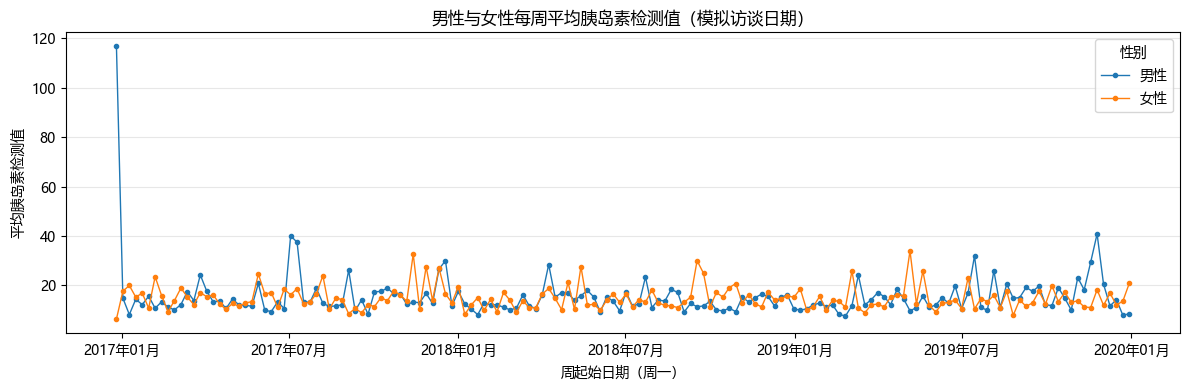

In [2]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from IPython.display import display

analysis_data = nhane.copy()

analysis_data['interview_day'] = pd.to_datetime(
    analysis_data['interview_day'], errors='coerce'
)
analysis_data['LBXIN'] = pd.to_numeric(analysis_data['LBXIN'], errors='coerce')
analysis_data = analysis_data.loc[
    analysis_data['RIAGENDR'].isin(['Male', 'Female'])
].dropna(subset=['interview_day', 'LBXIN'])

analysis_data['week'] = analysis_data['interview_day'].dt.to_period('W-SUN')
weekly_insulin = (
    analysis_data.groupby(['week', 'RIAGENDR'])['LBXIN']
    .mean()
    .unstack('RIAGENDR')
    .reindex(columns=['Male', 'Female'])
    .sort_index()
)

weekly_display = weekly_insulin.rename(
    columns={'Male': '男性', 'Female': '女性'}
).rename_axis(index='周区间', columns='性别')
weekly_display.index = [
    f'{week.start_time:%Y年%m月%d日}至{week.end_time:%Y年%m月%d日}'
    for week in weekly_insulin.index
]
weekly_display.index.name = '周区间'
with pd.option_context('display.max_rows', None):
    display(weekly_display.round(2))

plt.rcParams['font.sans-serif'] = ['Microsoft YaHei', 'SimHei', 'DejaVu Sans']
plt.rcParams['axes.unicode_minus'] = False

fig, ax = plt.subplots(figsize=(12, 4))
for gender, label in [('Male', '男性'), ('Female', '女性')]:
    ax.plot(
        weekly_insulin.index.start_time,
        weekly_insulin[gender],
        label=label,
        marker='.',
        linewidth=1
    )
ax.set(
    title='男性与女性每周平均胰岛素检测值（模拟访谈日期）',
    xlabel='周起始日期（周一）',
    ylabel='平均胰岛素检测值'
)
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=6))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y年%m月'))
ax.legend(title='性别')
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()
